In [1]:
# !pip install pandas seaborn matplotlib

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# load and save a copy of the earthquake dataset
earthquake = pd.read_csv('https://raw.githubusercontent.com/mosesyhc/de300-2026wi/refs/heads/main/datasets/Canadian-Earthquakes-2010-2019.csv')

In [7]:
# take a glimpse of the data
earthquake.head()

,magnitude_codelist,magnitude,magnitude_type,date,place,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom
0,<2,1.7,ML,2010-01-01T00:16:49+0000,81 km NE of Seattle,0.0,48.192001,-121.677002,1,-121.677315,48.191706
1,2,2.2,MN,2010-01-01T00:52:50+0000,86 km NW from Maniwaki,18.0,47.028999,-76.583000,2,-76.583303,47.028909
2,<2,1.8,MN,2010-01-01T03:21:58+0000,21 km NW from Mont-Laurier,18.0,46.651001,-75.734001,3,-75.733902,46.650809
3,<2,1.5,MN,2010-01-01T04:14:51+0000,CHARLEVOIX SEISMIC ZONE,13.0,47.740002,-69.741997,4,-69.742000,47.740210
4,<2,1.6,ML,2010-01-01T04:15:17+0000,83 km W of Gold R.,11.6,49.500999,-127.222000,5,-127.222216,49.500705


In [9]:
# view a summary of the full data
earthquake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44561 entries, 0 to 44560
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   magnitude_codelist  44561 non-null  object 
 1   magnitude           44561 non-null  float64
 2   magnitude_type      44462 non-null  object 
 3   date                44561 non-null  object 
 4   place               44561 non-null  object 
 5   depth               44561 non-null  float64
 6   latitude            44561 non-null  float64
 7   longitude           44561 non-null  float64
 8   OBJECTID            44561 non-null  int64  
 9   longitude_geom      44561 non-null  float64
 10  latitude_geom       44561 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 3.7+ MB


In [11]:
# checks for duplicates (also ask if duplicates make sense)
earthquake.duplicated()

# .loc / .iloc

0        False
1        False
2        False
3        False
4        False
         ...  
44556    False
44557    False
44558    False
44559    False
44560    False
Length: 44561, dtype: bool

In [13]:
# a quick numerical summary 
earthquake.describe(include='all')

,magnitude_codelist,magnitude,magnitude_type,date,place,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom
count,44561,44561.000000,44462,44561,44561,44561.000000,44561.000000,44561.000000,44561.000000,44561.000000,44561.000000
unique,6,NaN,7,44481,18639,NaN,NaN,NaN,NaN,NaN,NaN
top,<2,NaN,ML,2018-07-02T04:08:13+0000,CHARLEVOIX SEISMIC ZONE,NaN,NaN,NaN,NaN,NaN,NaN
freq,19764,NaN,29509,3,1250,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.134070,NaN,NaN,NaN,12.852194,53.351863,-118.953322,22281.000000,-118.953299,53.351830
std,NaN,0.828096,NaN,NaN,NaN,9.963145,6.214464,23.696484,12863.797009,23.696493,6.214465
min,NaN,-1.400000,NaN,NaN,NaN,-0.500000,40.808998,-148.811005,1.000000,-148.810526,40.808509
25%,NaN,1.600000,NaN,NaN,NaN,5.000000,49.169998,-132.427994,11141.000000,-132.427618,49.170009
50%,NaN,2.100000,NaN,NaN,NaN,10.000000,52.137001,-129.671997,22281.000000,-129.672016,52.136507
75%,NaN,2.700000,NaN,NaN,NaN,18.000000,56.514999,-121.947998,33421.000000,-121.948318,56.515206


In [15]:
# checks for possible statistical assumption(s)
import scipy.stats as sps

sps.normaltest(earthquake['magnitude'])

NormaltestResult(statistic=1597.6658124732546, pvalue=0.0)

In [17]:
# extract only numeric variables
earthquake

,magnitude_codelist,magnitude,magnitude_type,date,place,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom
0,<2,1.7,ML,2010-01-01T00:16:49+0000,81 km NE of Seattle,0.0,48.192001,-121.677002,1,-121.677315,48.191706
1,2,2.2,MN,2010-01-01T00:52:50+0000,86 km NW from Maniwaki,18.0,47.028999,-76.583000,2,-76.583303,47.028909
2,<2,1.8,MN,2010-01-01T03:21:58+0000,21 km NW from Mont-Laurier,18.0,46.651001,-75.734001,3,-75.733902,46.650809
3,<2,1.5,MN,2010-01-01T04:14:51+0000,CHARLEVOIX SEISMIC ZONE,13.0,47.740002,-69.741997,4,-69.742000,47.740210
4,<2,1.6,ML,2010-01-01T04:15:17+0000,83 km W of Gold R.,11.6,49.500999,-127.222000,5,-127.222216,49.500705
...,...,...,...,...,...,...,...,...,...,...,...
44556,<2,1.8,ML,2019-12-31T18:37:24+0000,"31 km SE of Ashcroft, BC",14.0,50.487999,-121.035004,44557,-121.035415,50.487806
44557,2,2.4,MN,2019-12-31T22:18:53+0000,"Blast, Laronde Mine, QC",0.0,48.250000,-78.448997,44558,-78.449004,48.250409
44558,2,2.0,ML,2019-12-31T23:11:07+0000,"29 km SE of Ashcroft, BC",10.5,50.526001,-121.005997,44559,-121.006115,50.526206
44559,<2,1.9,MN,2019-12-31T23:53:23+0000,"6 km N from Cornwall, ON",18.0,45.083000,-74.718002,44560,-74.718302,45.083409


In [20]:
# for example, normality test
sps.shapiro(earthquake['magnitude'])

/Applications/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 44561.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=0.9877396508026004, pvalue=1.1797749855829162e-49)

In [22]:
# pairwise correlation
earthquake_num = earthquake.select_dtypes('number')
import numpy as np
np.corrcoef(earthquake_num.iloc[:500])

array([[1.        , 0.99283184, 0.99298537, ..., 0.48916592, 0.49048782,
        0.48978772],
       [0.99283184, 1.        , 0.99996723, ..., 0.4266156 , 0.42805465,
        0.42737408],
       [0.99298537, 0.99996723, 1.        , ..., 0.43309795, 0.43453491,
        0.43385882],
       ...,
       [0.48916592, 0.4266156 , 0.43309795, ..., 1.        , 0.99999838,
        0.99999864],
       [0.49048782, 0.42805465, 0.43453491, ..., 0.99999838, 1.        ,
        0.99999955],
       [0.48978772, 0.42737408, 0.43385882, ..., 0.99999864, 0.99999955,
        1.        ]])

In [24]:
sns.set(context='talk', style='ticks')  # simply for aesthetics
sns.set_palette('magma')
%matplotlib inline 

# earthquake = earthquake.sample(n=500)  # (if too slow) for illustration purposes

## Plot 1: Magnitude Distribution

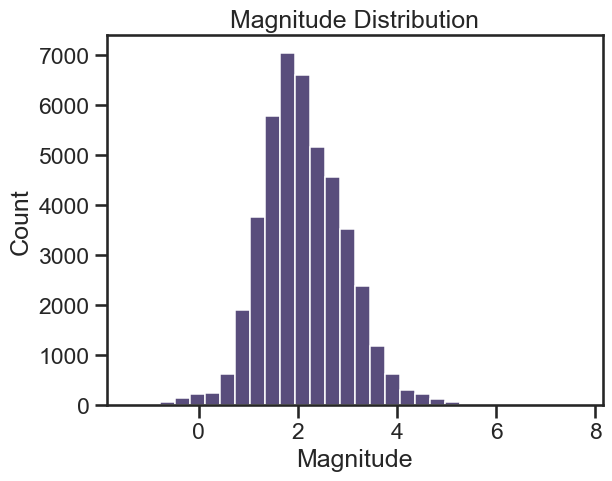

In [41]:
sns.histplot(earthquake['magnitude'], bins=30)
plt.title('Magnitude Distribution')
plt.xlabel('Magnitude')
plt.ylabel('Count')
plt.show()

## Plot 2: Magnitude vs Depth (Scatter) 


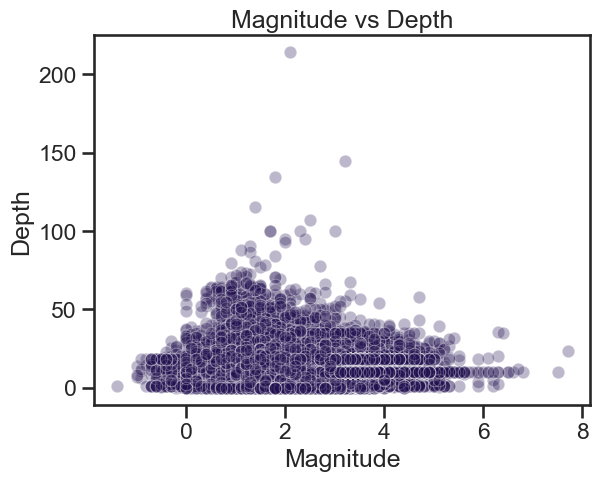

In [44]:
sns.scatterplot(
    data=earthquake,
    x='magnitude',
    y='depth',
    alpha=0.3, 
)

plt.title('Magnitude vs Depth')
plt.xlabel('Magnitude')
plt.ylabel('Depth')
plt.show()